In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from micrograd.engine import Value
from micrograd.nn import Neuron, Layer, MLP
np.random.seed(135)
random.seed(135)

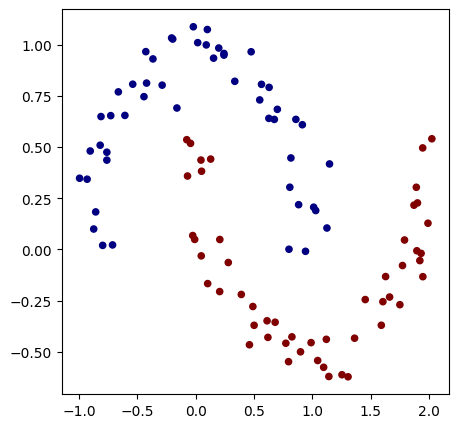

In [2]:
# make up a dataset

from sklearn.datasets import make_moons, make_blobs
X, y = make_moons(n_samples=100, noise=0.1)
# Make two interleaving half circles.
# A simple toy dataset to visualize clustering and classification
# algorithms. Read more in the :ref:`User Guide <sample_generators>`.

# X : ndarray of shape (n_samples, 2)
#     The generated samples.

# y : ndarray of shape (n_samples,)
#     The integer labels (0 or 1) for class membership of each sample.

y = y*2 - 1 # make y be -1 or 1
# visualize in 2D
plt.figure(figsize=(5,5))
plt.scatter(X[:,0], X[:,1], c=y, s=20, cmap='jet')  # 画的是X的两个数据维度，颜色表示y

In [3]:
# initialize a model 

model = MLP(2, [16,16,1])  # 一个两层的神经网络，但是要拟合的数据比较复杂，所以网络的每层用的神经元比较多
print("model", model)
print("number of parameters", len(model.parameters()))

model MLP of [Layer of [ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2)], Layer of [ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16)], Layer of [LinearNeuron(16)]]
number of parameters 337


之前因为只有四个样本，数据很少，所以每次都计算所有数据的损失

现在是100个样本，样本数量多了，所以就考虑使用batch的方法来进行

In [4]:
b = ["123", "12"]
a = list(map(int, b))
a

[123, 12]

In [6]:
# 损失函数，其实这里把前向过程和损失放一起了
def loss(batch_size = None):
    if batch_size is None:
        Xb, Yb = X,y  # 没有规定batch的话，就直接全部样本
    else:
        ri = np.random.permutation(X.shape[0])[:batch_size]  # Randomly permute a sequence, or return a permuted range.
        Xb, Yb = X[ri], y[ri]

    # 把批量输入转为Value类型 类似 list(map(int, "123", "12"])) = [123, 12]
    # 其实不需要执行这步,因为 engine里实现了Value的__radd__等操作，可以直接对普通的int对象进行计算
    # inputs = [list(map(Value, xrow)) for xrow in Xb]
    # inputs = list(map(Value, Xb)) 
    # print(inputs) # batch_size = 3时, [Value(data = [0.79899228 0.00112067], grad = 0), Value(data = [-0.99471742  0.34797772], grad = 0), Value(data = [1.89949885 0.22736301], grad = 0)]

    # 执行前向过程获取scores
    # scores = list(map(model, inputs))
    scores = list(map(model, Xb))
    
    # 计算loss, svm "max-margin" loss max(0, 1-y*f(x))
    # 这里的yi要么是1, 要么是-1
    # 这里的 .relu() 等价于 max(0, x)
    # losses = [max(0, 1-yi*score) for yi,score in zip(Yb,scores)]
    losses = [(1 - yi*score).relu() for yi,score in zip(Yb,scores)] 
    # 损失归一化
    data_loss = sum(losses) * (1.0 / len(losses))
    # data_loss = sum(losses)/len(losses)
    # L2正则
    alpha = 1e-4
    L2_norm = alpha*sum((p*p for p in model.parameters()))
    # 完整的svm损失函数
    total_loss = data_loss + L2_norm

    # 准确率
    accuracy = [(yi > 0) == (score.data > 0) for yi, score in zip(Yb, scores)]
    # print(accuracy)
    return total_loss, sum(accuracy)/len(accuracy)

In [7]:
score = Value(0.6)
1-1.0*score, 1+ -1.0*score  

# 一开始上面出现以下结果,是因为 __rsub__函数写错了
# (Value(data = -0.4, grad = 0), Value(data = 0.4, grad = 0))
# def __rsub__(self, other): # other - self
#     return self + (-other)

# 改为下面这样，就会得到正确结果
# (Value(data = 0.4, grad = 0), Value(data = 0.4, grad = 0))
# def __rsub__(self, other): # other - self
#     return other + (-self)

(Value(data = 0.4, grad = 0), Value(data = 0.4, grad = 0))

In [8]:
import random
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from micrograd.engine import Value
from micrograd.nn import Neuron, Layer, MLP
seed = 1337
np.random.seed(1337)
random.seed(1337)
from sklearn.datasets import make_moons, make_blobs

model = MLP(2, [16,16,1])  # 一个两层的神经网络，但是要拟合的数据比较复杂，所以网络的每层用的神经元比较多
X, y = make_moons(n_samples=100, noise=0.1)
y = y*2 - 1 

# 开始迭代权重/优化
for k in range(100):
    # 前向
    total_loss, acc = loss()
    # 反向
    model.zero_grad()
    total_loss.backward()
    # 优化
    learning_rate = 1.0 - 0.9*k/100   # lr schedule k=0，lr=1； k=50，lr=0.55; k=100, lr=0.1; 学习率线性变化

    for p in model.parameters():
        p.data -= learning_rate*p.grad

    if k % 1 == 0:
        print(f"step {k} loss {total_loss.data}, accuracy {acc*100}%")
# 如果上面的L2正则的系数设置为 alpha = 1e-2 （即非常夸张的防止过拟合），则训练100轮最多94%的准确率

step 0 loss 0.8047240913088219, accuracy 76.0%
step 1 loss 1.019451966431712, accuracy 81.0%
step 2 loss 0.5967730400885078, accuracy 85.0%
step 3 loss 0.40888186420758654, accuracy 85.0%
step 4 loss 0.503221231174086, accuracy 84.0%
step 5 loss 0.46016776059381415, accuracy 82.0%
step 6 loss 0.571283256428741, accuracy 83.0%
step 7 loss 0.3203863938470172, accuracy 88.0%
step 8 loss 0.3229228321611383, accuracy 86.0%
step 9 loss 0.33288731821697537, accuracy 86.0%
step 10 loss 0.4799394380975237, accuracy 84.0%
step 11 loss 0.307206034201238, accuracy 89.0%
step 12 loss 0.33372818174021357, accuracy 87.0%
step 13 loss 0.32122470334554026, accuracy 85.0%
step 14 loss 0.42238268731215856, accuracy 85.0%
step 15 loss 0.2731413693155881, accuracy 90.0%
step 16 loss 0.31896935310657976, accuracy 88.0%
step 17 loss 0.278937691335155, accuracy 87.0%
step 18 loss 0.3393206973616121, accuracy 88.0%
step 19 loss 0.25197836997238365, accuracy 89.0%
step 20 loss 0.2841685990159037, accuracy 89.0%

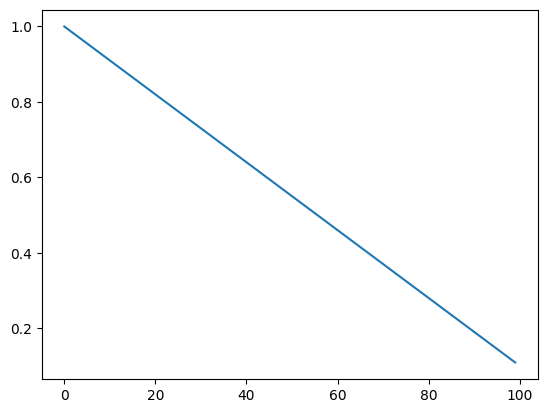

In [11]:
x = np.array(list(range(100)))
plt.plot(x, 1.0-0.9*x/100)

(-1.548639298268643, 1.951360701731357)

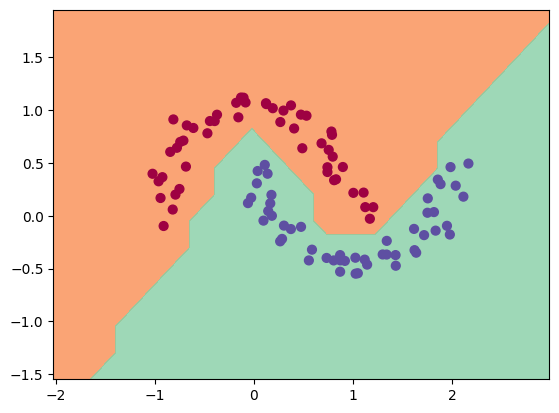

In [9]:
# visualize decision boundary

h = 0.25
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))
Xmesh = np.c_[xx.ravel(), yy.ravel()]

inputs = [list(map(Value, xrow)) for xrow in Xmesh]
scores = list(map(model, inputs))

Z = np.array([s.data > 0 for s in scores])
Z = Z.reshape(xx.shape)

fig = plt.figure()
plt.contourf(xx, yy, Z, cmap=plt.cm.Spectral, alpha=0.8)
plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.Spectral)
plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())

# Max-Margin loss（L2正则）

[动手学深度学习V2.0(Pytorch)——12. 权重衰退](https://stitch.blog.csdn.net/article/details/120745903)

## ✅️✅️✅️Max-Margin

Hinge Loss 是如何实现 Max-Margin 的？

在 SVM 中，我们通常假设标签 $y \in \{-1, 1\}$，线性分类器的预测函数为 $f(x) = w^T x + b$。

#### 第一步：如何判断分类正确？
如果 $y$ 和 $f(x)$ 同号，说明分类正确。即：
$$y \cdot f(x) > 0$$
这个值被称为**函数间隔**。

#### 第二步：引入“安全边界”（Margin）
仅仅 $y \cdot f(x) > 0$ 是不够的，因为如果 $y \cdot f(x) = 0.0001$，虽然分对了，但样本点几乎就贴在决策边界上，非常危险。
SVM 规定：**不仅要求分对，还要求“自信地分对”**。我们设定一个安全阈值（通常归一化为 1），要求：
$$y \cdot f(x) \ge 1$$
* 如果 $y \cdot f(x) \ge 1$：样本不仅分对了，而且落在了“安全边界”之外（或者正好在边界上）。此时，我们认为它是**完美分类**，不需要任何惩罚，**Loss = 0**。
* 如果 $y \cdot f(x) < 1$：样本要么分错了（$<0$），要么虽然分对了但太靠近边界（在 $0$ 到 $1$ 之间）。此时需要惩罚，**Loss > 0**。

#### 第三步：Hinge Loss 公式
综合上述逻辑，单个样本的 Hinge Loss（合页损失，因为函数图像像一个合页/铰链）定义为：
$$L_{hinge} = \max(0, 1 - y \cdot f(x))$$

**公式拆解：**
* 当 $y \cdot f(x) \ge 1$ 时，$1 - y \cdot f(x) \le 0$，$\max$ 函数取 $0$。Loss 为 0。
* 当 $y \cdot f(x) < 1$ 时，$1 - y \cdot f(x) > 0$，$\max$ 函数取 $1 - y \cdot f(x)$。Loss 随 $y \cdot f(x)$ 的减小而线性增大。

---

### 3. SVM 的完整目标函数（结构风险最小化）

✅️✅️✅️**如果仅仅最小化 Hinge Loss，模型可能会通过无限放大 $w$ 和 $b$ 来让所有的 $y \cdot f(x)$ 都大于 1，这会导致过拟合**✅️✅️✅️。因此，SVM 的完整损失函数（目标函数）是 **经验风险 + 正则化项**：

$$J(w, b) = \underbrace{\frac{1}{N} \sum_{i=1}^{N} \max(0, 1 - y_i(w^T x_i + b))}_{\text{Hinge Loss (经验风险)}} + \underbrace{\lambda ||w||^2}_{\text{L2 正则化}}$$

**这里隐藏着 "Max-Margin" 的终极秘密：**
在几何上，两类样本之间的**几何间隔**（真实的物理距离）公式是 $\frac{2}{||w||}$。
* 为了让几何间隔 $\frac{2}{||w||}$ **最大**（Max-Margin）。
* 等价于让分母 $||w||$ **最小**。
* 等价于让 $||w||^2$ **最小**。

**结论：** 
SVM 目标函数中的 **Hinge Loss 负责保证所有样本满足函数间隔 $\ge 1$**，而 **$||w||^2$ 正则项负责在满足条件的前提下把 $w$ 压到最小，从而在几何上实现了 Max-Margin（最大化真实物理间隔）**。两者完美结合。

---

### 4. Hinge Loss 的独特性质（对比其他 Loss）

为了更深刻理解，我们把 Hinge Loss 和逻辑回归的交叉熵损失（Log Loss）以及 0-1 损失做个对比：

| 损失函数 | 公式 | 特点与 SVM 的关联 |
| :--- | :--- | :--- |
| **0-1 损失** | $I(y \cdot f(x) < 0)$ | 分对为0，分错为1。是 SVM 真正想优化的目标，但**不连续、不可导**，无法用梯度下降优化。 |
| **Hinge Loss** | $\max(0, 1 - y \cdot f(x))$ | **0-1 损失的最佳凸代理（Surrogate）**。连续且分段线性，易于优化。 |
| **Log Loss (交叉熵)**| $\log(1 + e^{-y \cdot f(x)})$ | 逻辑回归使用。**即使分得再对，Loss 也趋近于 0 但不为 0**。 |

#### Hinge Loss 带来的两大核心优势：
1. **产生稀疏性（支持向量的由来）**：
   对于 Hinge Loss，只要样本满足 $y \cdot f(x) \ge 1$（即远离决策边界的“良民”），它的 Loss 就严格为 0，对梯度没有贡献。
   **只有那些 $y \cdot f(x) < 1$ 的样本（即落在边界上或边界内的“支持向量”）才会产生 Loss 并参与模型更新。** 这使得 SVM 模型非常轻量，预测时只需要计算支持向量。
2. **对异常值（Outliers）更鲁棒**：
   对于交叉熵损失，如果一个异常点被分到了极其错误的地方（$y \cdot f(x)$ 是一个很大的负数），Loss 会呈指数级爆炸，把整个模型带偏。而 Hinge Loss 是**线性增长**的，对极端异常值的惩罚是有限且温和的。

### 总结

* **Max-Margin** 是 SVM 的灵魂思想：寻找离所有样本都最远的决策边界，以获得最强泛化能力。
* **Hinge Loss** $\max(0, 1 - y \cdot f(x))$ 是这一思想的数学表达：它不仅要求分类正确，还要求分类的“置信度”大于 1（建立安全边界）。
* 配合 **$||w||^2$ 正则化**，SVM 在数学优化上完美等价于在特征空间中寻找那个 **Max-Margin** 的超平面。

## ✅️✅️✅️L2正则

✅️✅️✅️**如果仅仅最小化 Hinge Loss，模型可能会通过无限放大 $w$ 和 $b$ 来让所有的 $y \cdot f(x)$ 都大于 1，这会导致过拟合**✅️✅️✅️
+ 所以这个过拟合风险，仅仅存在于是二分类的情况，即：仅仅是这个 `hinge loss` 才会存在这个问题
+ 主要是认为，`w`过大，可能会刚好碰巧适合数据集里的某些情况（主要是刚好遇到二分类的 `hinge loss` 这个bug）
+ 其实其他场景，可能不怎么容易遇到这个问题吧

### 1. 一句话概括
**L2 Regularization（L2 正则化）**，在深度学习中通常也被称为 **Weight Decay（权重衰减）**。它的核心思想是：**在模型训练时，通过惩罚过大的权重参数，限制模型的复杂度，从而防止过拟合（Overfitting）。**

---

### 2. 直观理解：为什么需要 L2 正则化？

假设你要训练一个模型来预测房价，输入特征有“房屋面积”和“门牌号”。
* **没有正则化时**：模型为了在训练集上达到极低的误差，可能会发现“门牌号”碰巧和某些高价房对应上了。于是，模型给“门牌号”分配了一个**极其巨大**的权重（比如 $w = 99999$），而给“面积”分配了较小的权重。这在训练集上表现很好，但在测试集上（门牌号变了）就会彻底崩溃，这就是**过拟合**。
* **加入 L2 正则化后**：L2 正则化相当于给模型定了一个规矩——**“你可以使用各种特征，但每个特征的权重都不能太大，大家要尽量均匀、平缓地发挥作用”**。如果模型试图给“门牌号”分配巨大的权重，L2 正则化就会施加严厉的惩罚，迫使模型放弃这种“走捷径”的行为，转而学习更通用、更平滑的规律（如“面积”）。

---

### 3. 数学原理：L2 正则化是什么？

在数学上，L2 正则化就是在原有的**数据损失（Data Loss）** 基础上，加上一个**正则化惩罚项（Regularization Penalty）**。

完整的损失函数（目标函数）公式如下：
$$J_{total} = \underbrace{J_{data}}_{\text{数据损失 (如 MSE, Hinge, 交叉熵)}} + \underbrace{\frac{\lambda}{2} \sum_{i=1}^{n} w_i^2}_{\text{L2 正则化项}}$$

* **$w_i$**：模型中所有的权重参数（通常不包含偏置 $b$）。
* **$\sum w_i^2$**：所有权重参数的**平方和**（这就是“L2”的由来，即 L2 范数的平方）。
* **$\lambda$ (lambda)**：**正则化强度**，是一个需要你手动设置的超参数。
  * $\lambda$ 越大，对大权重的惩罚越狠，模型越简单（容易欠拟合）。
  * $\lambda$ 越小，惩罚越弱，模型越复杂（容易过拟合）。   → ✅️**一般会认为, 参数越大,可以拟合的范围就越大,模型就越复杂**
* **$\frac{1}{2}$**：只是为了在**求导时让公式更美观**（平方求导会带出一个 2，和 $\frac{1}{2}$ 抵消），不影响本质。

#### 为什么它又被称为“权重衰减 (Weight Decay)”？
当我们对 $J_{total}$ 求导并进行梯度下降更新权重时，更新公式会变成：
$$w_{new} = w_{old} - \eta \left( \frac{\partial J_{data}}{\partial w} + \lambda w_{old} \right)$$
稍微变形一下：
$$w_{new} = w_{old} \underbrace{(1 - \eta \lambda)}_{\text{小于1的衰减系数}} - \eta \frac{\partial J_{data}}{\partial w}$$

你会发现，在每次更新前，旧的权重 $w_{old}$ 都会先乘以一个小于 1 的数 $(1 - \eta \lambda)$。**这意味着，无论梯度怎么变，权重在每次迭代时都会自动向 0 “衰减”一点点。** 这就是 Weight Decay 名字的由来。

### 5. 补充：L2 与 L1 正则化的简单对比

为了让你知识体系更完整，简单提一下它的“兄弟” L1 正则化：

| 特性 | L2 正则化 (Ridge / Weight Decay) | L1 正则化 (Lasso) |
| :--- | :--- | :--- |
| **数学公式** | 权重平方和 $\sum w_i^2$ | 权重绝对值之和 $\sum |w_i|$ |
| **惩罚效果** | 让所有权重都变得**很小且均匀**，趋近于 0 但不等于 0。 | 让很多不重要的权重**直接变成绝对的 0**。 |
| **核心作用** | 防止过拟合，使模型更平滑（深度学习最常用）。 | 产生**稀疏模型**，自带特征选择功能（传统机器学习常用）。 |
| **求导难度** | 处处可导，优化非常平滑。 | 在 0 点不可导，优化相对麻烦。 |

### 总结
* **是什么**：L2 正则化就是在 Loss 里加上“所有权重平方和”的惩罚，逼迫模型不要依赖个别巨大的权重，从而防止过拟合。
* **怎么用**：在 PyTorch 中设置优化器的 `weight_decay`；在手写底层代码中，手动计算 `sum(w*w)` 并乘以系数 $\lambda$ 加到 `total_loss` 里。